In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Get stock data
ticker_value = 'SPY'
ticker = yf.Ticker(ticker_value)
df = ticker.history(period="2y")

In [5]:
def calculate_bollinger_bands(df, window=20, num_std=2):
    """
    Calculate Bollinger Bands for the given dataframe
    
    Parameters:
    df (pd.DataFrame): DataFrame with stock price data
    window (int): Moving average window size
    num_std (int): Number of standard deviations for the bands
    
    Returns:
    tuple: (middle band, upper band, lower band)
    """
    # Calculate middle band (20-day moving average)
    middle_band = df['Close'].rolling(window=window).mean()
    
    # Calculate standard deviation
    rolling_std = df['Close'].rolling(window=window).std()
    
    # Calculate upper and lower bands
    upper_band = middle_band + (rolling_std * num_std)
    lower_band = middle_band - (rolling_std * num_std)
    
    return middle_band, upper_band, lower_band

def generate_signals(df, upper_band, lower_band):
    """
    Generate buy/sell signals based on Bollinger Bands
    
    Parameters:
    df (pd.DataFrame): DataFrame with stock price data
    upper_band (pd.Series): Upper Bollinger Band
    lower_band (pd.Series): Lower Bollinger Band
    
    Returns:
    tuple: (buy signals, sell signals)
    """
    buy_signals = []
    sell_signals = []
    
    # Initialize position flag (1 = in position, 0 = out of position)
    in_position = 0
    
    for i in range(len(df)):
        if df['Close'].iloc[i] <= lower_band.iloc[i] and not in_position:
            buy_signals.append(i)
            in_position = 1
        elif df['Close'].iloc[i] >= upper_band.iloc[i] and in_position:
            sell_signals.append(i)
            in_position = 0
        else:
            continue
            
    return buy_signals, sell_signals

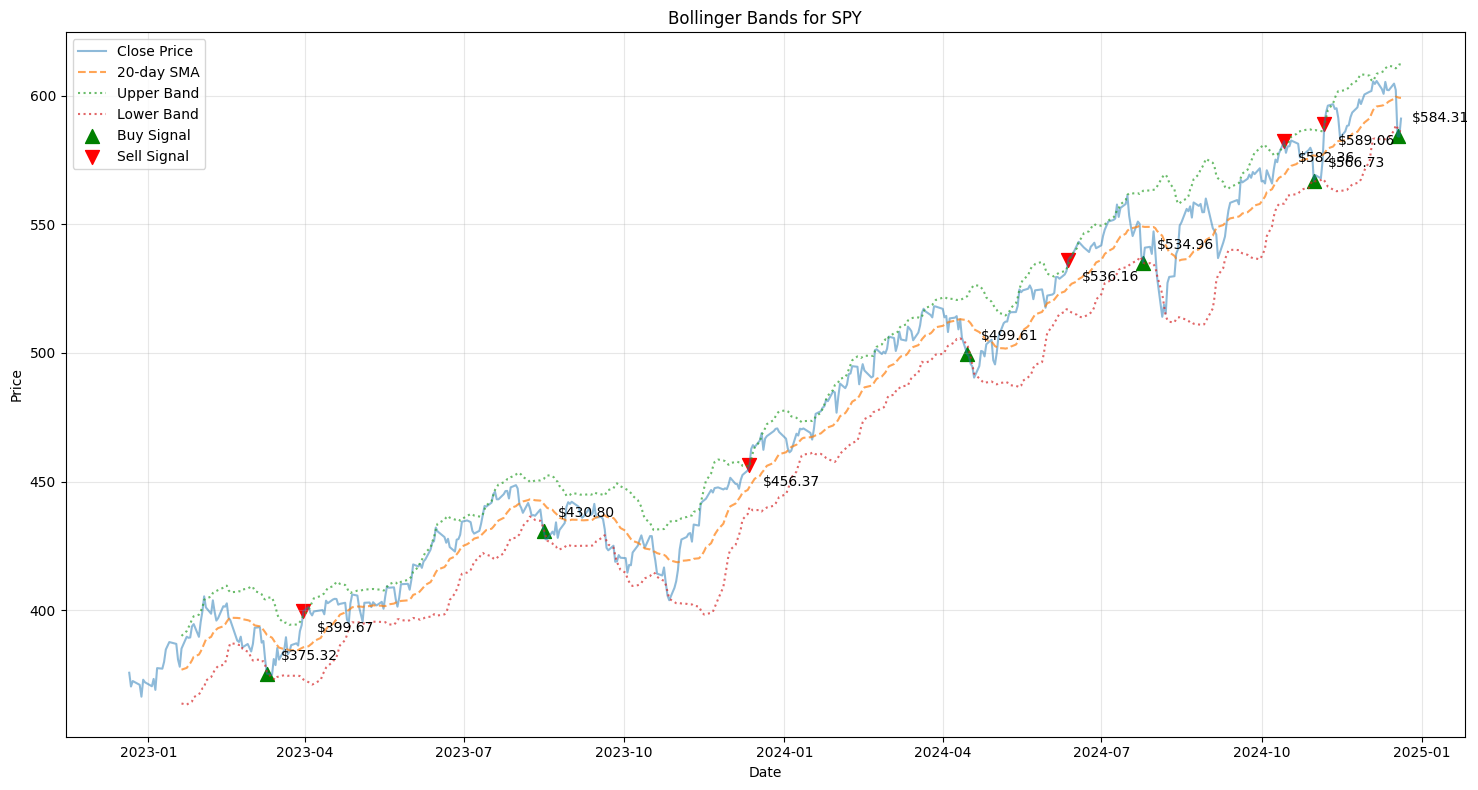


Trade Summary:
Number of buy signals: 6
Number of sell signals: 5

Trade 1:
Buy Date: 2023-03-10, Price: $375.32
Sell Date: 2023-03-31, Price: $399.67
Profit/Loss: 6.49%

Trade 2:
Buy Date: 2023-08-16, Price: $430.80
Sell Date: 2023-12-12, Price: $456.37
Profit/Loss: 5.94%

Trade 3:
Buy Date: 2024-04-15, Price: $499.61
Sell Date: 2024-06-12, Price: $536.16
Profit/Loss: 7.32%

Trade 4:
Buy Date: 2024-07-25, Price: $534.96
Sell Date: 2024-10-14, Price: $582.36
Profit/Loss: 8.86%

Trade 5:
Buy Date: 2024-10-31, Price: $566.73
Sell Date: 2024-11-06, Price: $589.06
Profit/Loss: 3.94%

Average Profit/Loss per trade: 6.51%


In [6]:
# Calculate Bollinger Bands
middle_band, upper_band, lower_band = calculate_bollinger_bands(df)

# Generate buy/sell signals
buy_signals, sell_signals = generate_signals(df, upper_band, lower_band)

# Create the plot
plt.figure(figsize=(15, 8))
plt.plot(df.index, df['Close'], label='Close Price', alpha=0.5)
plt.plot(df.index, middle_band, label='20-day SMA', linestyle='--', alpha=0.7)
plt.plot(df.index, upper_band, label='Upper Band', linestyle=':', alpha=0.7)
plt.plot(df.index, lower_band, label='Lower Band', linestyle=':', alpha=0.7)

# Plot buy signals
for signal in buy_signals:
    plt.scatter(df.index[signal], df['Close'].iloc[signal], 
                marker='^', color='green', s=100, label='Buy Signal' if signal == buy_signals[0] else '')

# Plot sell signals
for signal in sell_signals:
    plt.scatter(df.index[signal], df['Close'].iloc[signal], 
                marker='v', color='red', s=100, label='Sell Signal' if signal == sell_signals[0] else '')

# Customize the plot
plt.title(f'Bollinger Bands for {ticker_value}')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)

# Add price annotations for signals
for signal in buy_signals:
    plt.annotate(f'${df["Close"].iloc[signal]:.2f}', 
                (df.index[signal], df['Close'].iloc[signal]),
                xytext=(10, 10), textcoords='offset points')
                
for signal in sell_signals:
    plt.annotate(f'${df["Close"].iloc[signal]:.2f}', 
                (df.index[signal], df['Close'].iloc[signal]),
                xytext=(10, -15), textcoords='offset points')

plt.tight_layout()
plt.show()

# Print trade summary
print("\nTrade Summary:")
print(f"Number of buy signals: {len(buy_signals)}")
print(f"Number of sell signals: {len(sell_signals)}")

# Calculate profit/loss for completed trades
completed_trades = min(len(buy_signals), len(sell_signals))
total_profit_loss = 0
for i in range(completed_trades):
    buy_price = df['Close'].iloc[buy_signals[i]]
    sell_price = df['Close'].iloc[sell_signals[i]]
    profit_loss = ((sell_price - buy_price) / buy_price) * 100
    print(f"\nTrade {i+1}:")
    print(f"Buy Date: {df.index[buy_signals[i]].strftime('%Y-%m-%d')}, Price: ${buy_price:.2f}")
    print(f"Sell Date: {df.index[sell_signals[i]].strftime('%Y-%m-%d')}, Price: ${sell_price:.2f}")
    print(f"Profit/Loss: {profit_loss:.2f}%")
    total_profit_loss += profit_loss

if completed_trades > 0:
    print(f"\nAverage Profit/Loss per trade: {total_profit_loss/completed_trades:.2f}%")